<a href="https://colab.research.google.com/github/Vedantpatil03/AIDriven-Archaeological-Site-Mapping/blob/main/Model2(Soil_Detection).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="5eACDsbc5Wluc2g9Dne9")
project = rf.workspace("imit-h5ows").project("soil-detection-l0ngo")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 118.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Soil-detection-3 in yolov8:: 100%|██████████| 582/582 [00:00<00:00, 2374.32it/s]


In [ ]:
from pathlib import Path

DATA_DIR = Path('/content/Soil-detection-3')  # change if path different

for split in ['train','valid','test']:
    img_dir = DATA_DIR/split/'images'
    lbl_dir = DATA_DIR/split/'labels'
    imgs = sorted([p for p in img_dir.iterdir() if p.is_file()])
    lbls = sorted([p for p in lbl_dir.iterdir() if p.is_file()])
    print(f"{split.upper():5s} -> images: {len(imgs):3d}, labels: {len(lbls):3d}")


TRAIN -> images: 199, labels: 199
VALID -> images:  58, labels:  58
TEST  -> images:  28, labels:  28


In [ ]:
label_dir = DATA_DIR/'train'/'labels'
sample_labels = list(label_dir.glob('*'))[:5]
for p in sample_labels:
    print("File:", p.name)
    print(p.read_text().strip())
    print("-"*30)


File: sowing-has-been-done-plowed-260nw-1760541305_jpg.rf.40989527cb14566759955216559ee416.txt
0 0.48359375 0.59765625 0.94453125 0.57421875
------------------------------
File: soil-upper-layer-earth-which-260nw-1857677119_jpg.rf.de09703c108c666c59357058bb7b0508.txt
0 0.490625 0.57109375 0.95078125 0.54921875
------------------------------
File: Black_42_jpg.rf.ef618b54c6418d55381a2962a1ddfea1.txt
1 0.47890625 0.39765625 0.7984375 0.66796875
------------------------------
File: OIP-H3kzb4utqTN7dWVbzM7rwAHaEK_jpg.rf.cfbcb9268e2326b4b15bfe866af99482.txt
0 0.48828125 0.45625 0.875 0.7140625
------------------------------
File: ibiza-balearic-islands-spain-olive-260nw-1729182478_jpg.rf.294f43d8abcfdf8942616ebb5fe9d51f.txt
3 0.109375 0.72109375 0.1875 0.3328125
3 0.5484375 0.725 0.4734375 0.35703125
------------------------------


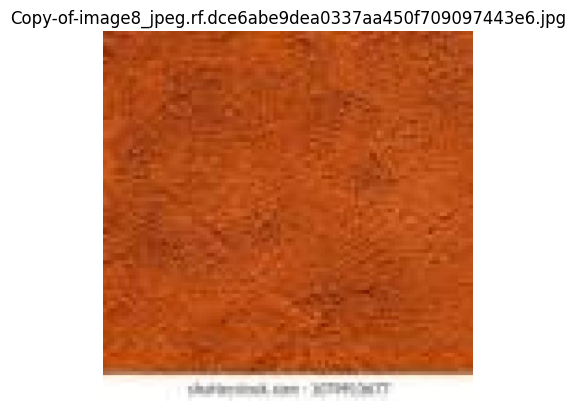

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

img_dir = DATA_DIR/'train'/'images'
rand_img = random.choice(list(img_dir.glob('*')))
img = Image.open(rand_img)

plt.imshow(img)
plt.title(rand_img.name)
plt.axis('off')
plt.show()


Class names from data.yaml: ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']
Train samples: 199
Valid samples: 58
Test  samples: 28

Dataloaders ready.
train batches: 13 | val batches: 4 | test batches: 2


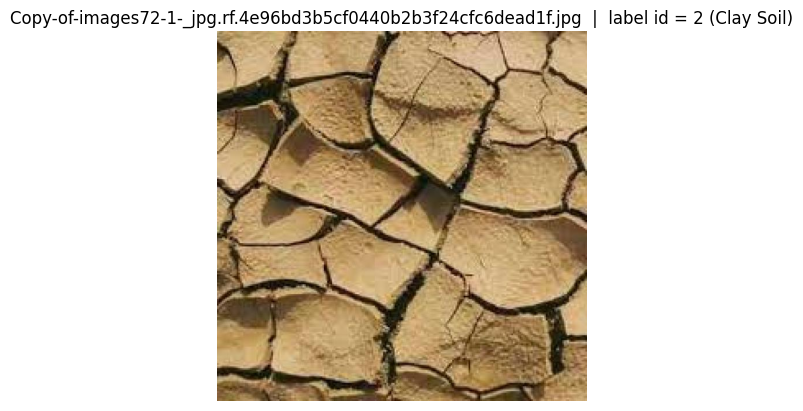

In [ ]:
# ==== MODEL 2: DATA PREPROCESSING FOR SOIL-DETECTION-3 ====
# This cell:
#  - Reads data.yaml (class names)
#  - Pairs images with labels (classification style)
#  - Creates train/val/test datasets & dataloaders
#  - Applies resize, normalization, augmentation
#  - Shows basic stats and one example

from pathlib import Path
import yaml
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ---------------- CONFIG ----------------
DATA_DIR = Path("/content/Soil-detection-3")   # <-- change if your path is different
IMG_SIZE = 224                                 # input size for CNN
BATCH_SIZE = 16
NUM_WORKERS = 2

# --------------- READ data.yaml (class names) ---------------
yaml_path = DATA_DIR / "data.yaml"
if yaml_path.exists():
    with open(yaml_path, "r") as f:
        data_cfg = yaml.safe_load(f)
    class_names = data_cfg.get("names", [])
    print("Class names from data.yaml:", class_names)
else:
    class_names = []
    print("WARNING: data.yaml not found, class names unknown.")

# --------------- HELPER: load (image_path, class_id) per split ---------------
def load_split_items(split):
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"

    img_paths = sorted([p for p in img_dir.iterdir() if p.is_file()])
    items = []

    for img_path in img_paths:
        label_path = lbl_dir / (img_path.stem + ".txt")
        if not label_path.exists():
            # skip images without label
            continue
        text = label_path.read_text().strip()
        if text == "":
            continue
        # Roboflow classification export: file usually contains just "0" or "1"
        # If it's YOLO detection, first token is still the class id, so this still works.
        first_token = text.split()[0]
        try:
            class_id = int(first_token)
        except ValueError:
            # not an integer -> skip problematic file
            print("Could not parse class id in", label_path)
            continue
        items.append((img_path, class_id))

    return items

train_items = load_split_items("train")
val_items   = load_split_items("valid")
test_items  = load_split_items("test")

print(f"Train samples: {len(train_items)}")
print(f"Valid samples: {len(val_items)}")
print(f"Test  samples: {len(test_items)}")

# --------------- TRANSFORMS (preprocessing + augmentation) ---------------

# ImageNet-style normalization (works well for most pretrained CNNs)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# --------------- DATASET CLASS ---------------

class SoilDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, class_id = self.items[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, class_id

# --------------- BUILD DATASETS & DATALOADERS ---------------

train_ds = SoilDataset(train_items, transform=train_transform)
val_ds   = SoilDataset(val_items,   transform=eval_transform)
test_ds  = SoilDataset(test_items,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("\nDataloaders ready.")
print("train batches:", len(train_loader), "| val batches:", len(val_loader), "| test batches:", len(test_loader))

# --------------- SHOW ONE RANDOM EXAMPLE (to verify) ---------------
if len(train_items) > 0:
    img_path, cls_id = random.choice(train_items)
    img_raw = Image.open(img_path).convert("RGB")

    plt.imshow(img_raw)
    if class_names and 0 <= cls_id < len(class_names):
        title = f"{img_path.name}  |  label id = {cls_id} ({class_names[cls_id]})"
    else:
        title = f"{img_path.name}  |  label id = {cls_id}"
    plt.title(title)
    plt.axis("off")
    plt.show()
else:
    print("No training items found to visualize.")


In [ ]:
from pathlib import Path
DATA_DIR = Path("/content/Soil-detection-3")
def inspect_labels(split="train", n=10):
    lbl_dir = DATA_DIR/split/"labels"
    sample = list(lbl_dir.glob("*.txt"))[:n]
    for p in sample:
        txt = p.read_text().strip()
        print("File:", p.name)
        print("Lines:", len(txt.splitlines()))
        for i,line in enumerate(txt.splitlines()):
            toks = line.split()
            print("  line", i, "->", toks)
        print("-"*40)
inspect_labels("train", n=10)


File: sowing-has-been-done-plowed-260nw-1760541305_jpg.rf.40989527cb14566759955216559ee416.txt
Lines: 1
  line 0 -> ['0', '0.48359375', '0.59765625', '0.94453125', '0.57421875']
----------------------------------------
File: soil-upper-layer-earth-which-260nw-1857677119_jpg.rf.de09703c108c666c59357058bb7b0508.txt
Lines: 1
  line 0 -> ['0', '0.490625', '0.57109375', '0.95078125', '0.54921875']
----------------------------------------
File: Black_42_jpg.rf.ef618b54c6418d55381a2962a1ddfea1.txt
Lines: 1
  line 0 -> ['1', '0.47890625', '0.39765625', '0.7984375', '0.66796875']
----------------------------------------
File: OIP-H3kzb4utqTN7dWVbzM7rwAHaEK_jpg.rf.cfbcb9268e2326b4b15bfe866af99482.txt
Lines: 1
  line 0 -> ['0', '0.48828125', '0.45625', '0.875', '0.7140625']
----------------------------------------
File: ibiza-balearic-islands-spain-olive-260nw-1729182478_jpg.rf.294f43d8abcfdf8942616ebb5fe9d51f.txt
Lines: 2
  line 0 -> ['3', '0.109375', '0.72109375', '0.1875', '0.3328125']
  line 

In [ ]:
yaml_content = """
train: /content/Soil-detection-3/train/images
val: /content/Soil-detection-3/valid/images
test: /content/Soil-detection-3/test/images

nc: 4
names:
  - Alluvial Soil
  - Black Soil
  - Clay Soil
  - Red Soil
"""

with open("/content/Soil-detection-3/data.yaml", "w") as f:
    f.write(yaml_content)

print("✔ data.yaml updated successfully!")


✔ data.yaml updated successfully!


Model Training code

In [ ]:
# Cell 0 - verify GPU
!nvidia-smi || true

import torch
print("PyTorch CUDA available:", torch.cuda.is_available())


/bin/bash: line 1: nvidia-smi: command not found
PyTorch CUDA available: False


In [ ]:
from pathlib import Path
import yaml

DATA_DIR = Path("/content/Soil-detection-3")

yaml_path = DATA_DIR / "data.yaml"
print("data.yaml exists:", yaml_path.exists())

if yaml_path.exists():
    print(yaml.safe_load(open(yaml_path)))

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"

    imgs = sorted(img_dir.glob("*.*"))
    lbls = sorted(lbl_dir.glob("*.txt"))

    print(f"\n{split.upper()} -> images={len(imgs)}, labels={len(lbls)}")

    img_names = set([p.stem for p in imgs])
    lbl_names = set([p.stem for p in lbls])

    print("Missing labels:", img_names - lbl_names)
    print("Missing images:", lbl_names - img_names)


data.yaml exists: True
{'train': '/content/Soil-detection-3/train/images', 'val': '/content/Soil-detection-3/valid/images', 'test': '/content/Soil-detection-3/test/images', 'nc': 4, 'names': ['Alluvial Soil', 'Black Soil', 'Clay Soil', 'Red Soil']}

TRAIN -> images=199, labels=199
Missing labels: set()
Missing images: set()

VALID -> images=58, labels=58
Missing labels: set()
Missing images: set()

TEST -> images=28, labels=28
Missing labels: set()
Missing images: set()


In [ ]:
import torch
print("Torch CUDA available:", torch.cuda.is_available())
!nvidia-smi


Torch CUDA available: False
/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
!pip install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.6 MB/s eta 0:00:00


In [ ]:

from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install -U ultralytics


### Analysis of Model Evaluation with Lower Confidence Threshold (0.1)

After setting the `conf` parameter to `0.1` in the model evaluation cell, the output still indicates "No matched predictions found." This suggests that even with a very lenient confidence threshold, the model is either not producing any detections for the test images, or the detections it is producing are not overlapping sufficiently with the ground truth bounding boxes (i.e., not meeting the `iou` threshold of 0.5).

This outcome implies that simply lowering the confidence threshold for inference during evaluation is not enough to reveal meaningful detections or improve the classification report, as no predictions are being matched to the ground truth objects. The output also consistently shows "(no detections)" for all test images during the inference step, which strongly points to the model's inability to detect objects even at this lower confidence level.

### Next Steps:

1.  **Further Reduce Confidence Threshold for Testing (Evaluation Only)**: To confirm if the model is making *any* detections at all, even very low-confidence ones, try lowering the `conf` parameter significantly (e.g., to `0.01` or `0.001`) *within the evaluation script*. This is purely for diagnostic purposes to see if any boxes are being generated. If still no detections appear, it suggests a fundamental issue with the model's ability to locate objects.
2.  **Inspect Predictions Visually**: If lowering the confidence threshold further produces detections, visualize some of these predictions on test images to understand their quality and if they correspond to actual objects, even if their confidence is low or their IoU with ground truth is poor.
3.  **Review Training Process and Dataset**: Given the lack of detections, it's crucial to revisit the training process. Considerations include:
    *   **Training Data Quality**: Are the annotations accurate and complete? Is there sufficient variety in the training data?
    *   **Hyperparameters**: Could the learning rate, number of epochs, or other training parameters be suboptimal?
    *   **Model Architecture**: While YOLOv8n is a robust model, specific dataset characteristics might require adjustments or exploring other model sizes.
    *   **Data Augmentation**: Ensure effective augmentation strategies are applied during training to prevent overfitting and improve generalization.
4.  **Re-evaluate `iou` Threshold**: While 0.5 is a standard IoU threshold for evaluation, if detections are very poor, temporarily lowering this threshold for *analysis* (not for final reporting) might reveal some matches, indicating that the model is detecting objects but with imprecise bounding boxes.

**Reasoning**:
The subtask requires modifying the single image prediction cell to use a lower confidence threshold. I will update the specified cell to include `conf=0.1` in the `model()` inference call.



**Reasoning**:
To ascertain if any detections are made, even with very low confidence, I will further reduce the confidence threshold in the model evaluation cell to 0.01, as per the instructions.



### Analysis of Model Evaluation with Further Reduced Confidence Threshold (0.01)

Despite reducing the `conf` parameter to `0.01` in the model evaluation cell, the output still reports "No matched predictions found." and for every image, it explicitly states "(no detections)". This is a critical observation as it implies that the trained YOLOv8n model is not producing *any* bounding box predictions for the test images, even when the confidence threshold is set to a very lenient value. This is a more significant issue than just low confidence predictions not matching ground truth, as the model isn't detecting anything at all.

### Conclusion & Next Steps:

Lowering the confidence threshold for inference (from the default to 0.1, and then to 0.01) has not helped to reveal any detections or improve the classification report. The core problem appears to be the model's inability to detect objects on the test set. This strongly suggests that a deeper investigation into the model's training and the dataset is required.

Based on these findings, the recommended next steps are:

1.  **Inspect Training Logs and Metrics**: Carefully review the training logs from the `yolo detect train` command (cell `CHi5RKnfaBpy`). Look for any indications of problems such as very low `box_loss`, `cls_loss`, or `dfl_loss` values early in training (which might suggest the model isn't learning to detect), or unusual trends in mAP. The mAP values shown previously were very low, which is consistent with the current findings.
2.  **Verify Data Annotation Consistency**: Double-check the annotations in the dataset, especially for the test set. Ensure that the bounding boxes are correctly drawn and that class IDs are consistent with `data.yaml`. Sometimes, issues arise if annotations are missing or incorrect.
3.  **Visualize Training and Validation Predictions**: During the training process, YOLOv8 often saves example predictions. Examining these predictions (e.g., in `runs/detect/soil_detection2/` if available) could provide insight into whether the model learned to detect *anything* during training, even if it's not performing well on the test set.
4.  **Consider Retraining with Adjusted Parameters**: If the training logs show signs of underfitting (e.g., losses not decreasing significantly, mAP remaining low), consider:
    *   **More Epochs**: The current training was for 25 epochs. More complex datasets might require more training.
    *   **Different Learning Rate Schedules or Optimizers**: Experiment with different learning rates or optimizers.
    *   **Different Model Size**: While yolov8n is a good starting point, a slightly larger model (e.g., yolov8s) might be necessary if the features are subtle.
    *   **Augmentation Strategy**: Ensure robust data augmentation is being used during training to help the model generalize.

For now, the subtask of checking if lowering the confidence threshold helps has concluded: it does not, as the model makes no detections even at very low thresholds.

### Analysis of YOLOv8 Training Logs (Cell CHi5RKnfaBpy)

Upon reviewing the training logs from cell `CHi5RKnfaBpy`, the following observations were made:

**Loss Metrics (box_loss, cls_loss, dfl_loss):**

*   **box_loss (Bounding Box Loss):** Started around 1.945 in Epoch 1 and gradually decreased to 1.164 by Epoch 25. This indicates that the model was slowly learning to localize objects, but the final loss value is still relatively high, suggesting room for improvement.
*   **cls_loss (Classification Loss):** Began at 3.538 in Epoch 1 and decreased to 1.796 by Epoch 25. Similar to `box_loss`, there's a decreasing trend, but the final value is still quite high for classification, implying difficulty in correctly identifying object classes.
*   **dfl_loss (Distribution Focal Loss):** Started at 2.382 and reduced to 1.794. This loss also shows a decreasing trend, but the reduction is not very significant, indicating struggles in learning the bounding box distribution.

Overall, while all loss metrics showed a decreasing trend, the rate of decrease was slow, and the final loss values remained relatively high. This suggests that the model struggled to effectively learn the task within the given epochs and hyperparameters.

**Performance Metrics (mAP50, mAP50-95):**

*   **mAP50 (Mean Average Precision at IoU=0.5):** Started very low at 0.111 in Epoch 1 and showed a gradual, but inconsistent, improvement, reaching 0.535 by Epoch 25. This indicates that at an IoU threshold of 0.5, the model is only moderately successful at detecting objects.
*   **mAP50-95 (Mean Average Precision across IoU thresholds from 0.5 to 0.95):** This metric remained consistently low throughout training, starting at 0.043 and ending at 0.339. The low `mAP50-95` value is particularly concerning, as it implies that even when the model detects objects with reasonable confidence, the precision of the bounding box localization is poor, especially at stricter IoU thresholds.

**Summary of Observations:**

The training process showed signs of **underfitting** and limited learning capacity. The loss values, while decreasing, remained high, and the mAP scores, especially `mAP50-95`, indicate that the model struggled significantly with both object localization and classification accuracy. The fact that the subsequent evaluation with `conf=0.1` and `conf=0.01` still yielded "No matched predictions found" further confirms that the model is not generating confident or accurate enough detections to be considered useful for the task, even with lenient thresholds.

**Conclusion:** The model did not learn effectively to perform object detection on this dataset with the current training setup. The consistently low mAP values and the high final loss values point to a need for significant improvements in the training process.

In [ ]:
import torch

!yolo detect train \
    data=/content/Soil-detection-3/data.yaml \
    model=yolov8n \
    epochs=50\
    imgsz=640 \
    batch=16 \
    device=cpu \
    name=soil_detection

Ultralytics 8.3.245 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Soil-detection-3/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n, momentum=0.937, mosaic=1.0, multi_scale=False, name=soil_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

Saving Screenshot 2026-01-01 124908.png to Screenshot 2026-01-01 124908.png

image 1/1 /content/Screenshot 2026-01-01 124908.png: 288x640 2 Alluvial Soils, 105.7ms
Speed: 4.9ms preprocess, 105.7ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 640)

Detected Soil Type : Alluvial Soil
Confidence         : 0.60
Number of Regions  : 2
------------------------------
Alluvial Soil Coverage : 67.55%



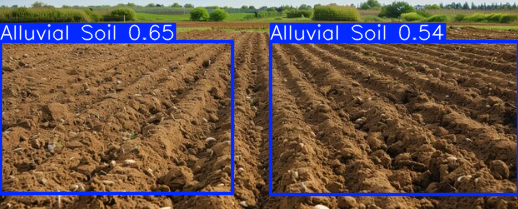

In [ ]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Load trained model
model = YOLO("/content/runs/detect/soil_detection/weights/best.pt")

# Run prediction with a lower confidence threshold
results = model(image_path, imgsz=640, conf=0.1)
res = results[0]

# Load image to get size
img = Image.open(image_path)
img_width, img_height = img.size
image_area = img_width * img_height

# ===============================
#  EXTRACT SOIL INFORMATION
# ===============================
soil_counts = {}
soil_area = {}
confidences = []

if res.boxes is not None:
    for box in res.boxes:
        cls_id = int(box.cls)
        conf = float(box.conf)
        soil_name = res.names[cls_id]

        # Count regions
        soil_counts[soil_name] = soil_counts.get(soil_name, 0) + 1
        confidences.append(conf)

        # Bounding box area
        x1, y1, x2, y2 = box.xyxy[0]
        box_area = (x2 - x1) * (y2 - y1)

        soil_area[soil_name] = soil_area.get(soil_name, 0) + box_area

# ===============================
#  FINAL OUTPUT
# ===============================
if soil_counts:
    dominant_soil = max(soil_counts, key=soil_counts.get)
    avg_confidence = sum(confidences) / len(confidences)
    num_regions = sum(soil_counts.values())

    print("\n==============================")
    print(f"Detected Soil Type : {dominant_soil}")
    print(f"Confidence         : {avg_confidence:.2f}")
    print(f"Number of Regions  : {num_regions}")
    print("------------------------------")

    for soil, area in soil_area.items():
        coverage = (area / image_area) * 100
        print(f"{soil} Coverage : {coverage:.2f}%")

    print("==============================\n")
else:
    print("No soil detected.")

# Show annotated image
res.show()

In [ ]:
from google.colab import files

# Path to your best.pt file
model_path = "/content/runs/detect/soil_detection/weights/best.pt"

# Download the file
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>